## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_validate, cross_val_score

# Linear Regression

🎯 In this exercise, you will model the performance of an NBA player's win rating (`win_rating`) according to their game statistics (like minutes played, `mp`). 

👉 Load the `NBA.csv` dataset into this notebook as a pandas dataframe, and display its first 5 rows.

In [4]:
# YOUR CODE HERE
df_nba = pd.read_csv('NBA.csv')
df_nba.head()

,season,poss,mp,do_ratio,pacing,win_rating
0,1987,4847,2409,-1.546275,-0.599918,1.643091
1,2017,5582,2708,0.996587,0.531888,10.808427
2,2016,4976,2407,0.242598,0.127976,3.054773
3,2021,1178,585,-1.343806,-1.201034,0.230004
4,1988,4534,2056,-1.813990,-0.128997,0.905614


ℹ️ You can read a detailed description of the dataset in the challenge README. Make sure to refer to it throughout the challenge.

## 1. Define Feature Set and Target

🎯 The first objective is to model the players' overall performance rating compared to peers, called *Wins Above Replacement*, (`win_rating`) against the minutes that they've played (`mp`)

👉 Assign those two variables to `X` and `y`. Remember that `X` is the feature(s), and `y` is the target.

In [8]:
# YOUR CODE HERE
X = df_nba[['mp']]
y = df_nba['win_rating']

👉 In a [scatter plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html), visualize the relationship between the rating and the minutes played.

Text(0, 0.5, 'win_rating')

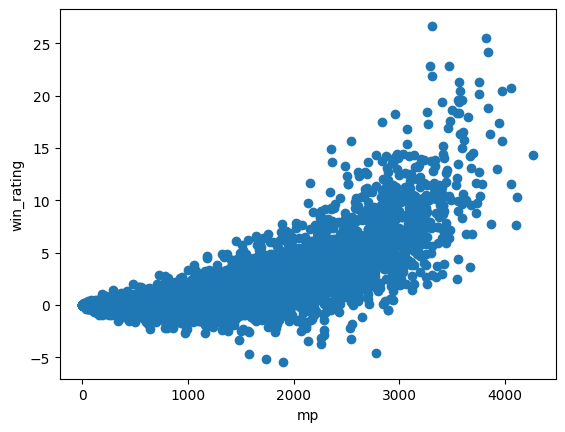

In [11]:
# YOUR CODE HERE

plt.scatter(X, y)

plt.xlabel('mp')
plt.ylabel('win_rating')

ℹ️ The scatter plot should hint that there is a relationship. But is it a perfectly linear relationship? 🤔 We'll see!

## 2. Cross-Validation

👉 Using Sklearn's [`cross_validate`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html), run a 5-fold cross-validation on a [`LinearRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) model predicting the player performance rating from minutes played. Save the raw output of the cross-validation under a new variable called `cv_results`.

In [20]:
# YOUR CODE HERE
from sklearn.model_selection import cross_validate

model = LinearRegression()

cv_results = cross_validate(model, X, y, cv=5)

cv_results


{'fit_time': array([0.0053494 , 0.00318694, 0.0041976 , 0.0017519 , 0.00172591]),
 'score_time': array([0.00279045, 0.00279093, 0.00241327, 0.00132895, 0.00218463]),
 'test_score': array([0.5555057 , 0.53447908, 0.53790391, 0.57658459, 0.57917762])}

❓ What is the lowest score of the cross-validation? Compute your answer and save the value under a new variable called `min_score`.

In [21]:
# YOUR CODE HERE

min_score = cv_results['test_score'].min()
min_score

0.5344790822272503

❓ What is the highest score of the cross-validation?  Compute your answer and save the value under a new variable called `max_score`.

In [22]:
# YOUR CODE HERE
max_score = cv_results['test_score'].max()
max_score

0.5791776193355004

❓ What is the mean score of the cross-validation? Compute your answer and save the value under a new variable called `mean_score`.

In [23]:
# YOUR CODE HERE
mean_score = cv_results['test_score'].mean()
mean_score

0.556730180006891

ℹ️ When running a cross-validation, we always look at the mean score as the most robust and representative evaluation of the model's performance.

### ☑️ Test your code

In [24]:
from nbresult import ChallengeResult

result = ChallengeResult(
    'cv_results',
    cv_result = cv_results,
    mean_score = mean_score
)

result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/gold/.pyenv/versions/lewagon/bin/python
cachedir: .pytest_cache
rootdir: /home/gold/code/abed-dvp/05-ML/01-Fundamentals-of-Machine-Learning/data-linear-regression/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 2 items

test_cv_results.py::TestCvResults::test_cv_mean PASSED                   [ 50%]
test_cv_results.py::TestCvResults::test_cv_results PASSED                [100%]

============================== 2 passed in 0.31s ===============================


💯 You can commit your code:

git add tests/cv_results.pickle

git commit -m 'Completed cv_results step'

git push origin master



🤔  **Let's now investigate the impact of the number of K-folds `K` (the `cv` parameter in `cross_validate()`)**

👉 Plot the evolution of **<u>total</u> computational time (fitting plus scoring)** and **<u>mean</u> score** as `K` increases from 2 to 20.

<details>
  <summary markdown='span'><strong>Hint</strong></summary>

  1. Create 3 lists to store the `K` values, computation times, and the cv mean scores.
  1. Loop over `K` values from 2 to 20, and each time:
     1. Run the cross validation
     1. Append the sum of `fit_time` and `score_time` to the list for your total times.
     1. Append the mean `test_score` to the list for your cv mean scores.
  1. Make two plots:
     1. Total time against `K`.
     1. Mean score against `K`.
</details>

In [25]:
# YOUR CODE HERE

In [26]:
# YOUR CODE HERE

ℹ️ You should see that the $R^2$ score stays stable, which is a good sign that the model performs equally on smaller and larger test sizes. Meanwhile, the computational time keeps increasing. For that reason, we do not exceed K = 10 as a rule of thumb.

## 3. Train the Model

Cross-validation is used to evaluate a hypothetical model on the dataset. It trains the chosen model multiple times (the number of folds you chose), each time on another subset of the data, using the rest of the data to calculate the score. This gives us a cross-validated score, telling us how good this model can perform.

If you want to use the model to make predictions, you prefer to train the model on as much data as possible. So, without putting part of the data aside.

👉 Go ahead and train the model on the full `X` and `y` (as we've already validated the model's score, and now will use it to predict). Save the trained model under the variable `model`.

In [27]:
# YOUR CODE HERE

❓ What is the slope (or coefficient) of your trained model? It can be accessed via the model's attributes. Save the slope under a variable named `slope`.

In [28]:
# YOUR CODE HERE

❓ What is the intercept of your trained model? It can be accessed via the model's attributes. Save the intercept under a variable named `intercept`.

In [29]:
# YOUR CODE HERE

🤔 Make sure you understand how to interpret these coefficients before moving on.

### ☑️ Test your code

In [30]:
from nbresult import ChallengeResult

result = ChallengeResult(
    'trained_model',
    slope = slope,
    intercept = intercept
)

result.write()
print(result.check())

NameError: name 'slope' is not defined

## 4. Predict

👉 Use your trained model to predict the performance rating of a player who has played 1000 minutes in total. Save the predicted value in a variable called `prediction`.

In [ ]:
new_datapoint = pd.DataFrame.from_dict(
    {"mp": [1000]}
)

# Make a prediction with the model
pass  # YOUR CODE HERE

### ☑️ Test your code

In [ ]:
from nbresult import ChallengeResult

result = ChallengeResult(
    'prediction',
    prediction = prediction
)

result.write()
print(result.check())

## 5. Improving the Model with More Features

Your friend who enjoys the NBA fantasy league comes to you with some insights 🏀

They say that when evaluating a player's Wins Above Replacement rating, they would typically also look at the number of ball possessions (`poss`), their defense/offense ratio (`do_ratio`), and their `pacing`.

❓ Run the cell below to visualize the correlation between these new features and the `win_rating`. Which **one** of the above features would you consider adding to your model?

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 6))

plt.subplots_adjust(left=0.5, right=2)

sns.regplot(data=df, y='win_rating', x='poss', ax=axes[0], scatter_kws={'alpha':0.5})
sns.regplot(data=df, y='win_rating', x='do_ratio', ax=axes[1], scatter_kws={'alpha':0.5})
sns.regplot(data=df, y='win_rating', x='pacing', ax=axes[2], scatter_kws={'alpha':0.5})

plt.show()

<details>
  <summary markdown='span'><strong>Answer</strong></summary>

  If you manually select features, you'd start with the ones with the highest correlation with the target, `win_rating`.

  Looking at the regression plots, that leaves us `poss` and `do_ratio`. Have a look at `df.corr()[['win_rating']]` if you prefer to see the numbers.

  Then why not `poss`, its correlation with `win_rating` is actually higher than `do_ratio`?

  Have a look at `sns.scatterplot(data=df, x='mp', y='poss');`. Do you see why?

  <details>
  <summary><strong>Answer</strong></summary>

  It seems that `mp`, our first feature, and `poss` are almost perfectly correlated. So `poss` would bring little extra value to our model.

  </details>

</details>

Now let's see if the model with two features (the new one you picked and `mp`) is better at predicting a player's rating than our first model.

👉 Create a new set of features - it should be a DataFrame with two columns.

In [ ]:
# YOUR CODE HERE

👉 Now cross-validate a new linear regression model and save the **mean** score to `mean_2_feat_score`.

> Note: if you only care about the cross-validation score (and not about the computation times), you can use sklearn's [`cross_val_score`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html)

In [ ]:
# YOUR CODE HERE

### ☑️ Test your code

In [ ]:
from nbresult import ChallengeResult

result = ChallengeResult(
    'improved_score',
    improved_score = mean_2_feat_score
)

result.write()
print(result.check())

You should see an **increase of around 8%** in your $R^2$ 👏

Congrats, you just performed your first manual *feature selection* - we'll see more ways to do that this week!

🤔 But is this the best we can do with Linear Regression? Let's explore more in the next challenge!

# 🏁